## K-Nearest Neighbors

K-Nearest Neighbors (KNN) is a simple, non-parametric, and lazy learning algorithm used for classification and regression tasks. It works by finding the K closest data points (neighbors) to a given input and making predictions based on the majority class (for classification) or the average value (for regression) of those neighbors.

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

data = {
    'x': [1, 3, 9, 4, 7, 1, 3, 4, 8, 2, 3, 4, 6, 8, 2, 4, 1, 3, 5, 
          8, 1, 2, 4, 6, 8, 9, 1, 2, 3, 5, 8],
    'y': [9, 9, 9, 8, 8, 7, 7, 7, 7, 5, 5, 5, 5, 5, 4, 4, 
          3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1],
    'label': ['Red', 'Red', 'Blue', 'Green', 'Blue', 'Blue', 
              'Blue', 'Red', 'Green', 'Purple', 'Purple', 'Purple', 'Red', 
              'Blue', 'Red', 'Green', 'Purple', 'Purple', 'Blue', 'Blue', 
              'Red', 'Purple', 'Purple', 'Red', 'Green', 'Blue', 'Purple', 
              'Green', 'Red', 'Purple', 'Blue']
}

df = pd.DataFrame(data)
# New predicted sample
A = [2, 8]

# Euclidean distance between A and all points in the dataset
df['Distance'] = np.sqrt((df['x'] - A[0])**2 + (df['y'] - A[1])**2)

print(df)

    x  y   label  Distance
0   1  9     Red  1.414214
1   3  9     Red  1.414214
2   9  9    Blue  7.071068
3   4  8   Green  2.000000
4   7  8    Blue  5.000000
5   1  7    Blue  1.414214
6   3  7    Blue  1.414214
7   4  7     Red  2.236068
8   8  7   Green  6.082763
9   2  5  Purple  3.000000
10  3  5  Purple  3.162278
11  4  5  Purple  3.605551
12  6  5     Red  5.000000
13  8  5    Blue  6.708204
14  2  4     Red  4.000000
15  4  4   Green  4.472136
16  1  3  Purple  5.099020
17  3  3  Purple  5.099020
18  5  3    Blue  5.830952
19  8  3    Blue  7.810250
20  1  2     Red  6.082763
21  2  2  Purple  6.000000
22  4  2  Purple  6.324555
23  6  2     Red  7.211103
24  8  2   Green  8.485281
25  9  2    Blue  9.219544
26  1  1  Purple  7.071068
27  2  1   Green  7.000000
28  3  1     Red  7.071068
29  5  1  Purple  7.615773
30  8  1    Blue  9.219544


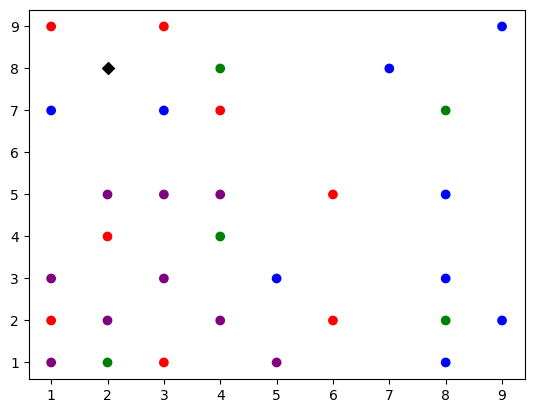

In [17]:
# Draw scatter plot (for reference)
plt.scatter(df['x'], df['y'], c=df['label'])
# Put A to the [2, 8] coordinate (show its name)
plt.scatter(A[0], A[1], c='black', marker='D')

In [18]:
# Select K and select the nearest K neighbors by sorting
K = 2
df_sorted = df.sort_values(by='Distance')
df_nearest = df_sorted.head(K)

print(df_nearest)

   x  y label  Distance
0  1  9   Red  1.414214
1  3  9   Red  1.414214


In [19]:
K = 4
df_sorted = df.sort_values(by='Distance')
df_nearest = df_sorted.head(K)

print(df_nearest)

   x  y label  Distance
0  1  9   Red  1.414214
1  3  9   Red  1.414214
5  1  7  Blue  1.414214
6  3  7  Blue  1.414214


We encounter class ties (2 Red and 2 Blue) alongside distance ties → In this case, the model select A = (2, 8) as Red since it occurs first.

In [20]:
K = 6
df_sorted = df.sort_values(by='Distance')
df_nearest = df_sorted.head(K)

print(df_nearest)

   x  y  label  Distance
0  1  9    Red  1.414214
1  3  9    Red  1.414214
5  1  7   Blue  1.414214
6  3  7   Blue  1.414214
3  4  8  Green  2.000000
7  4  7    Red  2.236068


Tie breaks!! The prediction for A = (2, 8) is Red because of major votes

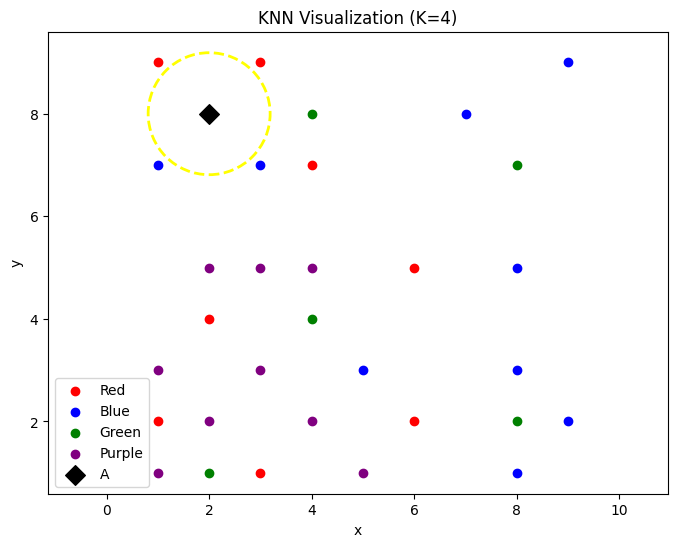

In [21]:
K = 4
df_nearest = df_sorted.head(K)
# Draw nearest neighbor circle for A
# Scatter plot of all points (color-coded by label)
plt.figure(figsize=(8,6))
for label, color in zip(['Red', 'Blue', 'Green', 'Purple'], ['red', 'blue', 'green', 'purple']):
    subset = df[df['label'] == label]
    plt.scatter(subset['x'], subset['y'], c=color, label=label)

# Plot point A
plt.scatter(A[0], A[1], c='black', marker='D', s=100, label='A')

# Draw circle around A that covers its K nearest neighbor(s)
# Circle radius = Euclidean distance to the farthest neighbor among K nearest
radius = np.sqrt(df_nearest['Distance'].max())
circle = plt.Circle((A[0], A[1]), radius, color='yellow', fill=False, linestyle='--', linewidth=2)
plt.gca().add_patch(circle)

plt.xlabel('x')
plt.ylabel('y')
plt.title(f'KNN Visualization (K={K})')
plt.legend()
plt.axis('equal')
plt.show()

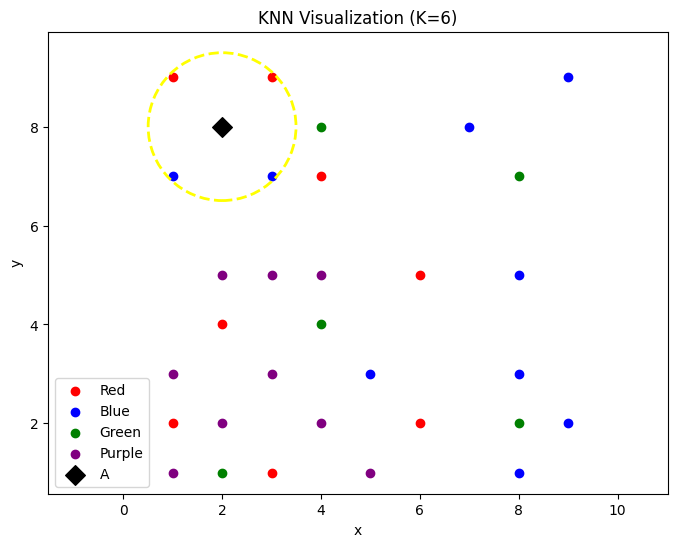

In [22]:
K = 6
df_nearest = df_sorted.head(K)
# Draw nearest neighbor circle for A
# Scatter plot of all points (color-coded by label)
plt.figure(figsize=(8,6))
for label, color in zip(['Red', 'Blue', 'Green', 'Purple'], ['red', 'blue', 'green', 'purple']):
    subset = df[df['label'] == label]
    plt.scatter(subset['x'], subset['y'], c=color, label=label)

# Plot point A
plt.scatter(A[0], A[1], c='black', marker='D', s=100, label='A')

# Draw circle around A that covers its K nearest neighbor(s)
# Circle radius = Euclidean distance to the farthest neighbor among K nearest
radius = np.sqrt(df_nearest['Distance'].max())
circle = plt.Circle((A[0], A[1]), radius, color='yellow', fill=False, linestyle='--', linewidth=2)
plt.gca().add_patch(circle)

plt.xlabel('x')
plt.ylabel('y')
plt.title(f'KNN Visualization (K={K})')
plt.legend()
plt.axis('equal')
plt.show()

Cross Validation in K-Nearest Neighbors

In [23]:
# Cross Validation with pandas and loops
def cross_validation(df):
  K_max = int(np.sqrt(len(df)))  # common heuristic
  accuracies = []

  # This loop tests all K from 1 to sqrt(N).
  for K in range(1, K_max+1):
      correct = 0
      for i in range(len(df)):
          # leave-one-out
          validation = df.iloc[i]
          train = df.drop(i)
          # compute distances to A
          train['Distance'] = (train['x'] - validation['x'])**2 + (train['y'] - validation['y'])**2
          nearest = train.sort_values('Distance').head(K)
          # majority vote
          votes = nearest['label'].value_counts()
          prediction = votes.idxmax()

          if prediction == validation['label']:
              correct += 1
      accuracies.append((K, correct/len(df)))
  # Accuracy for each K → pick the best K.
  return accuracies, max(accuracies)[0]


accuracies, best_K = cross_validation(df)
print("Accuracies:", accuracies)
print("Best K:", best_K)

Accuracies: [(1, 0.16129032258064516), (2, 0.16129032258064516), (3, 0.25806451612903225), (4, 0.3225806451612903), (5, 0.41935483870967744)]
Best K: 5


Now, we will classify these points to one of the labels.
- A = (2, 8)
- B = (6, 7)
- C = (7, 5)
- D = (2, 3)
- E = (7, 2)
- F = (4, 1)

With Cross-Validation

In [24]:
# A = (2, 8) is already predicted as Red, so we skip it
# B = (6, 7), C = (7, 5), D = (2, 3), E = (7, 2), F = (4, 1)
# New predicted sample
points = [[6, 7], [7, 5], [2, 3], [7, 2], [4, 1]]
for p in range(len(points)):
  # Euclidean distance between the given point and all points
  df[f'Distance_{p}'] = (df['x'] - points[p][0]) ** 2 + (df['y'] - points[p][1]) ** 2

  # Sort by distance and get the nearest K neighbors
  df_sorted = df.sort_values(by=f'Distance_{p}')
  df_nearest = df_sorted.head(best_K)
  print(f"Point {points[p]} - Nearest Neighbors:\n{df_nearest}\n")

Point [6, 7] - Nearest Neighbors:
    x  y  label  Distance  Distance_0
4   7  8   Blue  5.000000           2
12  6  5    Red  5.000000           4
7   4  7    Red  2.236068           4
8   8  7  Green  6.082763           4
3   4  8  Green  2.000000           5

Point [7, 5] - Nearest Neighbors:
    x  y  label  Distance  Distance_0  Distance_1
13  8  5   Blue  6.708204           8           1
12  6  5    Red  5.000000           4           1
19  8  3   Blue  7.810250          20           5
8   8  7  Green  6.082763           4           5
18  5  3   Blue  5.830952          17           8

Point [2, 3] - Nearest Neighbors:
    x  y   label  Distance  Distance_0  Distance_1  Distance_2
17  3  3  Purple  5.099020          25          20           1
16  1  3  Purple  5.099020          41          40           1
14  2  4     Red  4.000000          25          26           1
21  2  2  Purple  6.000000          41          34           1
20  1  2     Red  6.082763          50          45   

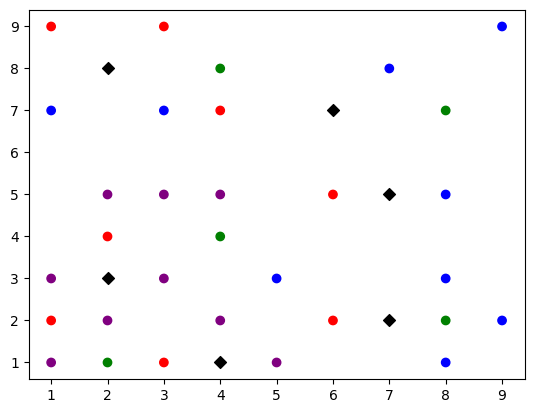

In [25]:
# Draw scatter plot (for reference)
plt.scatter(df['x'], df['y'], c=df['label'])
# Put A to the [2, 8] coordinate (show its name)
plt.scatter(A[0], A[1], c='black', marker='D')
for p in range(len(points)):
  plt.scatter(points[p][0], points[p][1], c='black', marker='D')

In [26]:
K = best_K
predicted_class = []
for i in df.drop(columns=['x', 'y', 'label']).columns:
  df_sorted = df.sort_values(by=i)
  df_nearest = df_sorted[['x', 'y', 'label']].head(K)
  print(f"Nearest Neighbors (k = {K})")
  print(df_nearest)
  predicted_class.append(df_nearest['label'].mode()[0])
  print(f"Predicted Class: {df_nearest['label'].mode()[0]} \n")

Nearest Neighbors (k = 5)
   x  y  label
0  1  9    Red
1  3  9    Red
5  1  7   Blue
6  3  7   Blue
3  4  8  Green
Predicted Class: Blue 

Nearest Neighbors (k = 5)
    x  y  label
4   7  8   Blue
12  6  5    Red
7   4  7    Red
8   8  7  Green
3   4  8  Green
Predicted Class: Green 

Nearest Neighbors (k = 5)
    x  y  label
13  8  5   Blue
12  6  5    Red
19  8  3   Blue
8   8  7  Green
18  5  3   Blue
Predicted Class: Blue 

Nearest Neighbors (k = 5)
    x  y   label
17  3  3  Purple
16  1  3  Purple
14  2  4     Red
21  2  2  Purple
20  1  2     Red
Predicted Class: Purple 

Nearest Neighbors (k = 5)
    x  y  label
24  8  2  Green
23  6  2    Red
30  8  1   Blue
19  8  3   Blue
25  9  2   Blue
Predicted Class: Blue 

Nearest Neighbors (k = 5)
    x  y   label
28  3  1     Red
22  4  2  Purple
29  5  1  Purple
27  2  1   Green
23  6  2     Red
Predicted Class: Purple 



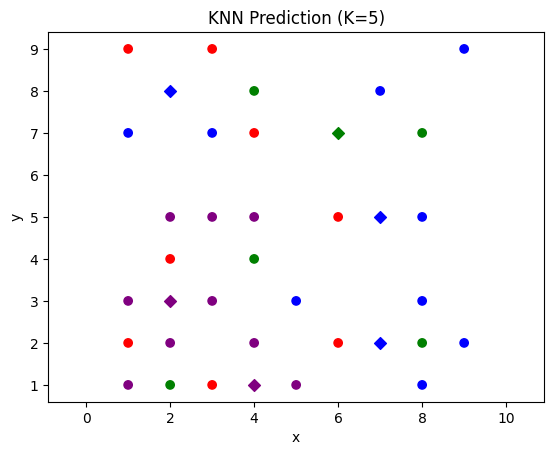

In [27]:
# Redraw the KNN plot
points = [[2, 8], [6, 7], [7, 5], [2, 3], [7, 2], [4, 1]]
plt.scatter(df['x'], df['y'], c=df['label'])
for p in range(len(points)):
  plt.scatter(points[p][0], points[p][1], c=predicted_class[p].lower(), marker='D')
plt.xlabel('x')
plt.ylabel('y')
plt.title(f'KNN Prediction (K={K})')
plt.axis('equal')
plt.show()

Optional: Choose K = 6

Nearest Neighbors (k = 6)
   x  y  label
0  1  9    Red
1  3  9    Red
5  1  7   Blue
6  3  7   Blue
3  4  8  Green
7  4  7    Red
Predicted Class: Red 

Nearest Neighbors (k = 6)
    x  y  label
4   7  8   Blue
12  6  5    Red
7   4  7    Red
8   8  7  Green
3   4  8  Green
13  8  5   Blue
Predicted Class: Blue 

Nearest Neighbors (k = 6)
    x  y  label
13  8  5   Blue
12  6  5    Red
19  8  3   Blue
8   8  7  Green
18  5  3   Blue
4   7  8   Blue
Predicted Class: Blue 

Nearest Neighbors (k = 6)
    x  y   label
17  3  3  Purple
16  1  3  Purple
14  2  4     Red
21  2  2  Purple
20  1  2     Red
27  2  1   Green
Predicted Class: Purple 

Nearest Neighbors (k = 6)
    x  y  label
24  8  2  Green
23  6  2    Red
30  8  1   Blue
19  8  3   Blue
25  9  2   Blue
18  5  3   Blue
Predicted Class: Blue 

Nearest Neighbors (k = 6)
    x  y   label
28  3  1     Red
22  4  2  Purple
29  5  1  Purple
27  2  1   Green
23  6  2     Red
21  2  2  Purple
Predicted Class: Purple 



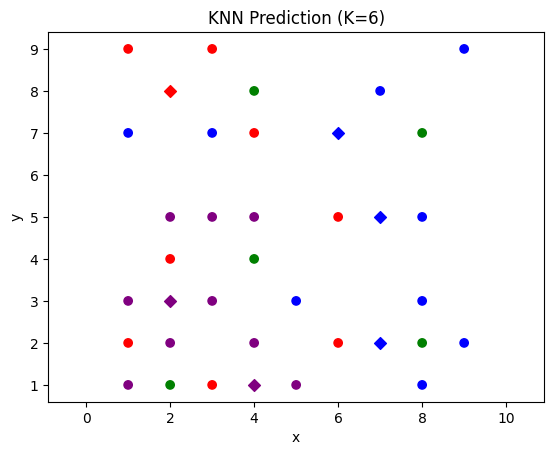

In [28]:
K = 6
predicted_class = []
for i in df.drop(columns=['x', 'y', 'label']).columns:
  df_sorted = df.sort_values(by=i)
  df_nearest = df_sorted[['x', 'y', 'label']].head(K)
  print(f"Nearest Neighbors (k = {K})")
  print(df_nearest)
  predicted_class.append(df_nearest['label'].mode()[0])
  print(f"Predicted Class: {df_nearest['label'].mode()[0]} \n")

# Redraw the KNN plot
points = [[2, 8], [6, 7], [7, 5], [2, 3], [7, 2], [4, 1]]
plt.scatter(df['x'], df['y'], c=df['label'])
for p in range(len(points)):
  plt.scatter(points[p][0], points[p][1], c=predicted_class[p].lower(), marker='D')
plt.xlabel('x')
plt.ylabel('y')
plt.title(f'KNN Prediction (K={K})')
plt.axis('equal')
plt.show()